# Шаблон для дизайна A/B-тестов

Непрерывная метрика (ARPU, средний чек и т. п.).

0. Параметры · 1. Рамка дизайна · 2. Калькулятор · 3. Проверки сплита · 4. Анализ · 5. Отчёт · 6. Ошибки

In [1]:
import math

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

rng = np.random.default_rng(42)

plt.rcParams.update({  # тихий стиль графиков: без рамки сверху/справа, бледная сетка
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.grid": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "text.color": "#0b0b0b", "axes.labelcolor": "#52514e",
    "xtick.color": "#898781", "ytick.color": "#898781",
})

## 0. Параметры

In [2]:
EXPERIMENT_NAME = "Новый экран оплаты"
ALPHA = 0.05
POWER = 0.8
MDE_REL = 0.05          # минимальный значимый эффект, в долях от среднего
SPLIT_RATIO = 1.0       # n_test / n_control
DAILY_USERS = 50_000    # новых пользователей в день
TRAFFIC_SHARE = 0.5     # доля трафика в эксперименте
USE_SYNTHETIC = True    # False = читаем history.csv и experiment.csv

## 1. Рамка дизайна

Заполняется до запуска.

- **Гипотеза:** если `<изменение>`, то `<метрика>` изменится минимум на `<MDE>`, потому что `<механизм>`
- **Аудитория и unit рандомизации:**
- **Целевая метрика** (одна):
- **Guardrail-метрики:**
- **Критерии решения:** SRM → тест невалиден; значимый рост и guardrail в порядке → выкатываем; значимое ухудшение → не выкатываем; незначимо → «не знаем»
- **Чек-лист:** A/A пройден, SRM-мониторинг настроен, правило по выбросам, не подглядываем

## 2. Калькулятор

$$n_A = \frac{(z_{1-\alpha/2} + z_{1-\beta})^2 \sigma^2 (1 + 1/k)}{MDE^2}, \quad k = n_B / n_A$$

In [3]:
def gen_arpu(n, pay_rate=0.3, mu=3.5, sigma=0.8):
    paid = rng.random(n) < pay_rate
    return np.where(paid, rng.lognormal(mu, sigma, n), 0.0)


if USE_SYNTHETIC:
    hist = pd.DataFrame({"user_id": np.arange(60_000), "metric": gen_arpu(60_000)})
else:
    hist = pd.read_csv("history.csv")   # user_id, metric

BASELINE_MEAN = hist["metric"].mean()
BASELINE_STD = hist["metric"].std()

In [4]:
def calc_n_control(sigma, mde, alpha=0.05, power=0.8, ratio=1.0):
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return math.ceil(z ** 2 * sigma ** 2 * (1 + 1 / ratio) / mde ** 2)


MDE_ABS = MDE_REL * BASELINE_MEAN
n_control = calc_n_control(BASELINE_STD, MDE_ABS, ALPHA, POWER, SPLIT_RATIO)
n_test = math.ceil(n_control * SPLIT_RATIO)
days = math.ceil((n_control + n_test) / (DAILY_USERS * TRAFFIC_SHARE))
days_weeks = math.ceil(days / 7) * 7

print(f"n: {n_control:,} / {n_test:,}; дней: {days} (до целых недель: {days_weeks})")

n: 35,009 / 35,009; дней: 3 (до целых недель: 7)


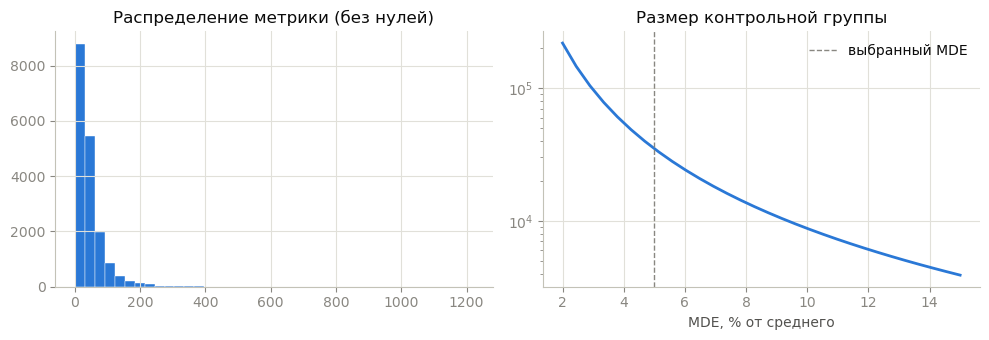

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

nonzero = hist.loc[hist["metric"] > 0, "metric"]
ax[0].hist(nonzero, bins=40, color="#2a78d6", edgecolor="white", linewidth=0.3)
ax[0].set_title("Распределение метрики (без нулей)")

mde_grid = np.linspace(0.02, 0.15, 30)
n_grid = [calc_n_control(BASELINE_STD, m * BASELINE_MEAN, ALPHA, POWER, SPLIT_RATIO) for m in mde_grid]
ax[1].plot(mde_grid * 100, n_grid, color="#2a78d6", linewidth=2)
ax[1].axvline(MDE_REL * 100, color="#898781", linestyle="--", linewidth=1, label="выбранный MDE")
ax[1].set_yscale("log")
ax[1].set_xlabel("MDE, % от среднего")
ax[1].set_title("Размер контрольной группы")
ax[1].legend(frameon=False)

plt.tight_layout()

## 3. Проверки сплита

- **A/A-тест:** доля ложных срабатываний ≈ α
- **SRM:** доли групп совпадают с заданными
- **Пре-период:** группы не отличались до старта

In [6]:
def aa_test(values, n_sims=500, alpha=0.05):
    n = len(values)
    hits = 0
    for _ in range(n_sims):
        in_a = rng.permutation(n) < n // 2
        hits += stats.ttest_ind(values[in_a], values[~in_a], equal_var=False).pvalue < alpha
    return hits / n_sims


def srm_check(counts, ratios=(1, 1), alpha=0.001):
    counts = np.asarray(counts, float)
    expected = np.asarray(ratios) / np.sum(ratios) * counts.sum()
    p = stats.chisquare(counts, expected).pvalue
    return {"p_value": p, "ok": p >= alpha}


def pre_period_check(pre_a, pre_b, alpha=0.01):
    p = stats.ttest_ind(pre_b, pre_a, equal_var=False).pvalue
    smd = (pre_b.mean() - pre_a.mean()) / np.sqrt((pre_a.var() + pre_b.var()) / 2)
    return {"p_value": p, "smd": smd, "ok": p >= alpha and abs(smd) < 0.1}


print(f"A/A: FPR = {aa_test(hist['metric'].to_numpy()):.3f}, ожидаем ≈ {ALPHA}")

A/A: FPR = 0.054, ожидаем ≈ 0.05


## 4. Анализ результатов

In [7]:
METRIC, PRE_METRIC = "arpu", "arpu_pre"
GUARDRAILS = {"sessions": "higher_better", "page_load_ms": "lower_better"}

if USE_SYNTHETIC:
    def make_group(n, lift):
        return pd.DataFrame({
            "arpu_pre": gen_arpu(n),
            "arpu": gen_arpu(n) * (1 + lift),
            "sessions": rng.poisson(5, n),
            "page_load_ms": rng.gamma(9, 50, n),
        })

    exp = pd.concat([make_group(n_control, 0).assign(group="A"),
                     make_group(n_test, 0.07).assign(group="B")], ignore_index=True)
else:
    exp = pd.read_csv("experiment.csv")   # user_id, group (A/B), метрики

a, b = exp[exp["group"] == "A"], exp[exp["group"] == "B"]

In [8]:
srm = srm_check([len(a), len(b)], ratios=[1, SPLIT_RATIO])
pre = pre_period_check(a[PRE_METRIC], b[PRE_METRIC])

print(f"SRM: p = {srm['p_value']:.3f}, ok = {srm['ok']}")
print(f"Пре-период: p = {pre['p_value']:.3f}, SMD = {pre['smd']:+.3f}, ok = {pre['ok']}")

SRM: p = 1.000, ok = True
Пре-период: p = 0.969, SMD = -0.000, ok = True


In [9]:
def analyze(a, b, alpha=0.05):
    diff = b.mean() - a.mean()
    se = np.sqrt(a.var() / len(a) + b.var() / len(b))
    z = stats.norm.ppf(1 - alpha / 2)
    return {
        "mean_a": a.mean(), "mean_b": b.mean(),
        "diff": diff, "rel_lift": diff / a.mean(),
        "ci": (diff - z * se, diff + z * se),
        "p_value": stats.ttest_ind(b, a, equal_var=False).pvalue,
    }


res = analyze(a[METRIC], b[METRIC], ALPHA)
print(f"Контроль {res['mean_a']:.3f}, тест {res['mean_b']:.3f}, "
      f"разница {res['diff']:+.3f} ({res['rel_lift']:+.2%}), "
      f"ДИ [{res['ci'][0]:+.3f}; {res['ci'][1]:+.3f}], p = {res['p_value']:.4f}")

Контроль 13.563, тест 14.555, разница +0.992 (+7.31%), ДИ [+0.508; +1.475], p = 0.0001


In [10]:
def bootstrap_rel_ci(a, b, alpha=0.05, n_boot=2000):
    # относительный эффект = отношение средних - 1, доверительный интервал перцентилями
    boot = np.array([rng.choice(b, len(b)).mean() / rng.choice(a, len(a)).mean() - 1 for _ in range(n_boot)])
    return boot, tuple(np.quantile(boot, [alpha / 2, 1 - alpha / 2]))


boot, res["rel_ci"] = bootstrap_rel_ci(a[METRIC].to_numpy(), b[METRIC].to_numpy(), ALPHA)
print(f"Относительный эффект, бутстрап-ДИ: [{res['rel_ci'][0]:+.2%}; {res['rel_ci'][1]:+.2%}]")

Относительный эффект, бутстрап-ДИ: [+3.91%; +11.10%]


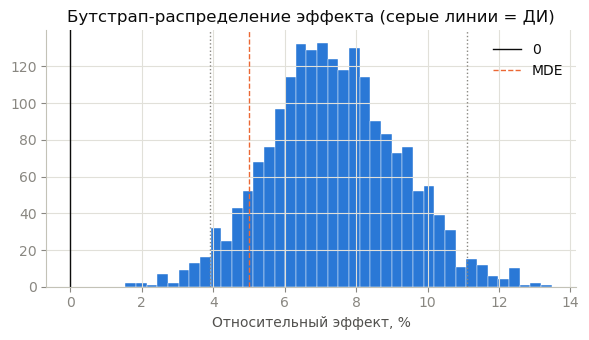

In [11]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(boot * 100, bins=40, color="#2a78d6", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="#0b0b0b", linewidth=1, label="0")
ax.axvline(MDE_REL * 100, color="#eb6834", linestyle="--", linewidth=1, label="MDE")
for x in res["rel_ci"]:
    ax.axvline(x * 100, color="#898781", linestyle=":", linewidth=1)
ax.set_xlabel("Относительный эффект, %")
ax.set_title("Бутстрап-распределение эффекта (серые линии = ДИ)")
ax.legend(frameon=False)
plt.tight_layout()

In [12]:
rows = []
for col, good in GUARDRAILS.items():
    r = analyze(a[col], b[col], ALPHA)
    rows.append({"метрика": col, "хорошо": good, "diff": r["diff"], "p_value": r["p_value"]})

guard = pd.DataFrame(rows)
guard["p_holm"] = multipletests(guard["p_value"], method="holm")[1]
worse = np.where(guard["хорошо"] == "higher_better", guard["diff"] < 0, guard["diff"] > 0)
guard["ухудшение"] = (guard["p_holm"] < ALPHA) & worse
guardrails_ok = not guard["ухудшение"].any()
guard

,метрика,хорошо,diff,p_value,p_holm,ухудшение
0,sessions,higher_better,-0.002885,0.864431,0.864431,False
1,page_load_ms,lower_better,-1.274364,0.257808,0.515617,False


In [13]:
def make_decision(res, mde_abs, valid, guardrails_ok, alpha):
    significant = res["p_value"] < alpha
    if not valid:
        return "ТЕСТ НЕВАЛИДЕН: SRM или дисбаланс на пре-периоде"
    if significant and res["diff"] > 0:
        return "ВЫКАТЫВАТЬ" if guardrails_ok else "НЕ ВЫКАТЫВАТЬ БЕЗ ОБСУЖДЕНИЯ: guardrail ухудшился"
    if significant:
        return "НЕ ВЫКАТЫВАТЬ: значимое ухудшение"
    if res["ci"][1] < mde_abs:
        return "ЗНАЧИМОГО ЭФФЕКТА НЕТ: верхняя граница ДИ ниже MDE"
    return "НЕДОСТАТОЧНО ДАННЫХ: «нет эффекта» утверждать нельзя"


decision = make_decision(res, MDE_ABS, srm["ok"] and pre["ok"], guardrails_ok, ALPHA)
decision

'ВЫКАТЫВАТЬ'

## 5. Отчёт

In [14]:
display(Markdown(f'''
### Отчёт: {EXPERIMENT_NAME}

**Решение:** {decision}

- Контроль / тест: {res['mean_a']:.3f} / {res['mean_b']:.3f} (n = {len(a):,} / {len(b):,})
- Разница: {res['diff']:+.3f} ({res['rel_lift']:+.2%}), {1 - ALPHA:.0%} ДИ [{res['ci'][0]:+.3f}; {res['ci'][1]:+.3f}], p = {res['p_value']:.4f}
- Относительный эффект, бутстрап-ДИ: [{res['rel_ci'][0]:+.2%}; {res['rel_ci'][1]:+.2%}]
- SRM: p = {srm['p_value']:.3f}; пре-период: SMD = {pre['smd']:+.3f}

**Выводы и следующие шаги:** …
'''))


### Отчёт: Новый экран оплаты

**Решение:** ВЫКАТЫВАТЬ

- Контроль / тест: 13.563 / 14.555 (n = 35,009 / 35,009)
- Разница: +0.992 (+7.31%), 95% ДИ [+0.508; +1.475], p = 0.0001
- Относительный эффект, бутстрап-ДИ: [+3.91%; +11.10%]
- SRM: p = 1.000; пре-период: SMD = -0.000

**Выводы и следующие шаги:** …


## 6. Типичные ошибки

- Подглядывание и остановка теста по достижении значимости
- MDE «под трафик», а не под бизнес
- Много метрик без поправки на множественные сравнения
- Игнорирование SRM
- Разные unit'ы в расчёте и в анализе
- Тест короче недели
- Выбросы убираются после просмотра результата